# **DATA COLLECTING AND CLEANING**

In [2]:
# Install and import all libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
import zipfile
warnings.filterwarnings('ignore')


zip_path = "/content/master_dataset.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content/data")

print("✅ ZIP extracted")

✅ ZIP extracted


In [8]:
import os
os.system('kaggle datasets download -d maitry09/fake-news --unzip')

0

In [9]:
# Load your dataset
df = pd.read_csv('master_dataset.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (49670, 3)

Columns: ['text', 'label', 'language']

First 5 rows:


,text,label,language
0,"मनीषा रानी पर भड़के एल्विश यादव, बोले- तू जो य...",0,Hindi_F&R_News
1,रिया ने अस्पताल में माफी मांगी थी गवाह\n\n\nहि...,0,Hindi_F&R_News
2,"केरल में फिर डरा रहे मामले, पिछले घंटे मेंनए क...",0,Hindi_F&R_News
3,एमएस धोनी के शागिर्द गेंद को मिली वनडे टीम में...,0,Hindi_F&R_News
4,प्रतिभा उम्र की मोहताज नहीं प्रेम चोपड़ा\n\n\n...,0,Hindi_F&R_News


In [10]:
# Basic exploration

print("=== Label distribution ===")
print(df['label'].value_counts())
print("\n0 = Fake | 1 = Real")

print("\n=== Language distribution ===")
print(df['language'].value_counts())

print("\n=== Missing values ===")
print(df.isnull().sum())

print("\n=== Sample from each language ===")
for lang in df['language'].unique():
    sample = df[df['language'] == lang]['text'].iloc[0]
    print(f"\n[{lang}]: {str(sample)[:120]}...")

=== Label distribution ===
label
1    30424
0    19246
Name: count, dtype: int64

0 = Fake | 1 = Real

=== Language distribution ===
language
Hindi_F&R_News       15100
Gujarati_F&R_News    14832
Telugu_F&R_News      11459
Marathi_F&R_News      8279
Name: count, dtype: int64

=== Missing values ===
text        0
label       0
language    0
dtype: int64

=== Sample from each language ===

[Hindi_F&R_News]: मनीषा रानी पर भड़के एल्विश यादव, बोले- तू जो ये चिपका-चिपकी करती है तेरे पति को क्लिप दिखाऊंगा…


बॉलीवुड सुपरस्टार सलमा...

[Telugu_F&R_News]: బిజెపిపై విమర్శగా కాంగ్రెస్ నాయకుడి వీడియోను మనేకా గాంధీ తప్పుగా పంచుకున్నారు
ఘజియాబాద్ కాంగ్రెస్ నాయకుడు డాలీ శర్మ వీడి...

[Marathi_F&R_News]: अलीकडील तुर्का भूकंप म्हणून असंबंधित दृश्यांची जाहिरात केली गेली
सीरियामधील तुर्क आणि अलीकडील भूकंपांचा व्हिडिओ म्हणून द...

[Gujarati_F&R_News]: શું ખરેખર ટ્રેક્ટર સાથે જોવા મળતીમહિલાઓ કિસાન આંદોલનમાં જોડાઈ…? જાણો શું છે સત્ય….
 ખેડૂતોના આંદોલનને લઈ સોશિયલ મિડિયામા...


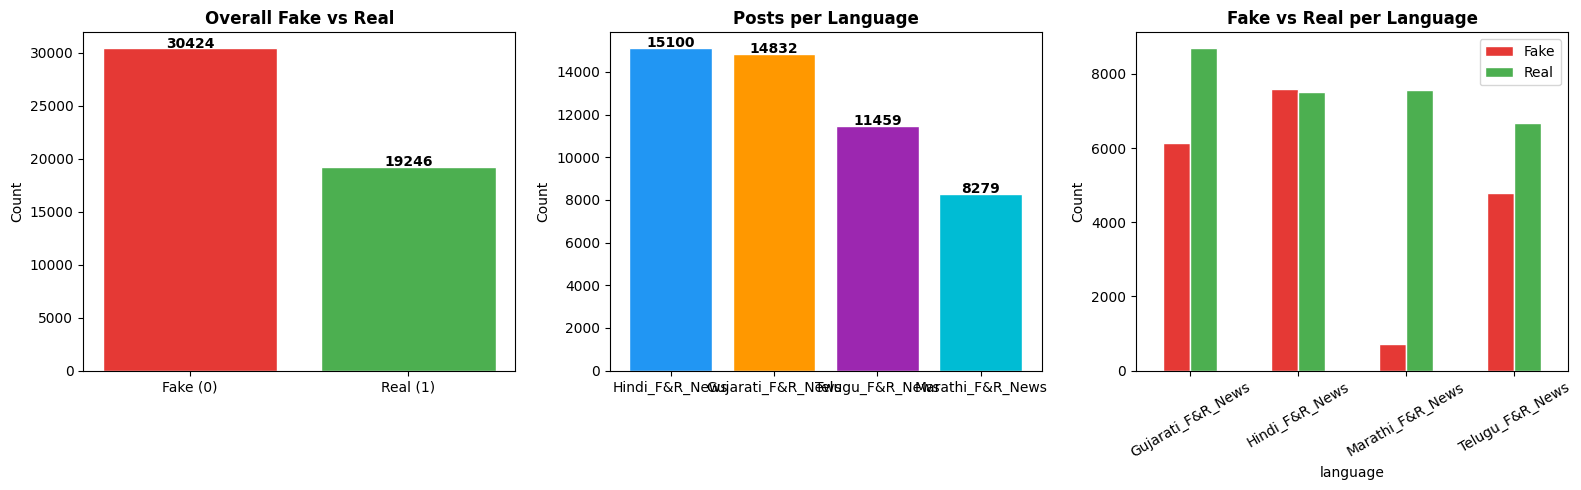

In [12]:
# Visualize distributions

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1 — Overall fake vs real
label_counts = df['label'].value_counts()
axes[0].bar(['Fake (0)', 'Real (1)'],
            label_counts.values,
            color=['#E53935', '#4CAF50'],
            edgecolor='white')
axes[0].set_title('Overall Fake vs Real', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 2 — Language distribution
lang_counts = df['language'].value_counts()
axes[1].bar(lang_counts.index, lang_counts.values,
            color=['#2196F3', '#FF9800', '#9C27B0', '#00BCD4'],
            edgecolor='white')
axes[1].set_title('Posts per Language', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(lang_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Plot 3 — Fake vs Real per language
lang_label = df.groupby(['language', 'label']).size().unstack()
lang_label.plot(kind='bar', ax=axes[2],
                color=['#E53935', '#4CAF50'],
                edgecolor='white')
axes[2].set_title('Fake vs Real per Language', fontweight='bold')
axes[2].set_ylabel('Count')
axes[2].legend(['Fake', 'Real'])
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [13]:
# Text cleaning

import re

def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'<.*?>', '', text)              # remove HTML tags
    text = re.sub(r'\s+', ' ', text).strip()       # remove extra spaces
    return text

# NOTE: Do NOT remove unicode/special chars
# because Gujarati, Hindi etc use unicode scripts
# removing them would destroy the text!

df['clean_text'] = df['text'].apply(clean_text)

# Remove very short texts
df = df[df['clean_text'].apply(lambda x: len(x.split()) >= 5)]

# Drop nulls and duplicates
df = df.dropna(subset=['clean_text', 'label', 'language'])
df = df.drop_duplicates(subset=['clean_text'])

print("After cleaning:", df.shape)
print("\nLanguage counts after cleaning:")
print(df['language'].value_counts())

After cleaning: (49426, 4)

Language counts after cleaning:
language
Hindi_F&R_News       15051
Gujarati_F&R_News    14830
Telugu_F&R_News      11424
Marathi_F&R_News      8121
Name: count, dtype: int64


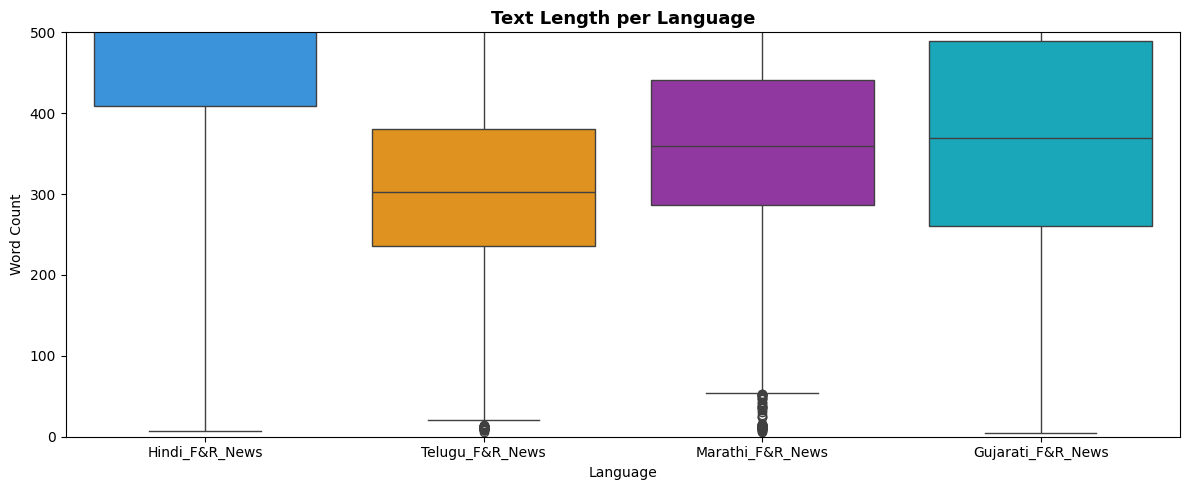


=== Average text length per language ===
language
Gujarati_F&R_News    385.1
Hindi_F&R_News       671.2
Marathi_F&R_News     363.8
Telugu_F&R_News      310.2
Name: text_length, dtype: float64


In [14]:
# Analyze text length per language

df['text_length'] = df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='language', y='text_length',
            palette=['#2196F3', '#FF9800', '#9C27B0', '#00BCD4'])
plt.title('Text Length per Language', fontsize=13, fontweight='bold')
plt.ylabel('Word Count')
plt.xlabel('Language')
plt.ylim(0, 500)
plt.tight_layout()
plt.savefig('text_length.png', dpi=150)
plt.show()

print("\n=== Average text length per language ===")
print(df.groupby('language')['text_length'].mean().round(1))

In [17]:
# Save cleaned dataset

df[['clean_text', 'label', 'language']].to_csv(
    'misinformation_cleaned.csv', index=False
)

print("Saved! Shape:", df.shape)
print("\nFinal label counts:")
print(df['label'].value_counts())
print("\nFinal language counts:")
print(df['language'].value_counts())

Saved! Shape: (49426, 5)

Final label counts:
label
1    30180
0    19246
Name: count, dtype: int64

Final language counts:
language
Hindi_F&R_News       15051
Gujarati_F&R_News    14830
Telugu_F&R_News      11424
Marathi_F&R_News      8121
Name: count, dtype: int64


In [18]:
#Shorten language names for cleaner plots and reports

df = pd.read_csv('misinformation_cleaned.csv')

# Clean language column
df['language'] = df['language'].str.replace('_F&R_News', '', regex=False)

print("Updated language names:")
print(df['language'].value_counts())

# Save updated file
df.to_csv('misinformation_cleaned.csv', index=False)
print("\nFile updated and saved!")

Updated language names:
language
Hindi       15051
Gujarati    14830
Telugu      11424
Marathi      8121
Name: count, dtype: int64

File updated and saved!


# **Baseline ML Models**

In [19]:
#Load cleaned data

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('misinformation_cleaned.csv')

print("Shape:", df.shape)
print("\nLanguage counts:")
print(df['language'].value_counts())
print("\nLabel counts:")
print(df['label'].value_counts())

# Features and labels
X = df['clean_text'].astype(str)
y = df['label'].astype(int)
lang = df['language']

print("\nData loaded successfully!")

Shape: (49426, 3)

Language counts:
language
Hindi       15051
Gujarati    14830
Telugu      11424
Marathi      8121
Name: count, dtype: int64

Label counts:
label
1    30180
0    19246
Name: count, dtype: int64

Data loaded successfully!


In [20]:
# Split data

X_train, X_test, y_train, y_test, lang_train, lang_test = train_test_split(
    X, y, lang,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps 60/40 ratio in both splits
)

print("Train size:", len(X_train))
print("Test size: ", len(X_test))
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())

Train size: 39540
Test size:  9886

Train label distribution:
label
1    24144
0    15396
Name: count, dtype: int64

Test label distribution:
label
1    6036
0    3850
Name: count, dtype: int64


In [21]:
# TF-IDF vectorizer for multilingual text

from sklearn.feature_extraction.text import TfidfVectorizer

# analyzer='char_wb' works better for Indian languagesbbecause word boundaries are different in Devanagari scripts
tfidf = TfidfVectorizer(
    max_features=50000,      # more features for 4 languages
    analyzer='char_wb',      # character n-grams — better for Indian scripts
    ngram_range=(2, 4),      # character 2-4 grams
    min_df=3,
    sublinear_tf=True
)

print("Fitting TF-IDF on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape: ", X_test_tfidf.shape)
print("TF-IDF ready!")

Fitting TF-IDF on training data...
Train TF-IDF shape: (39540, 50000)
Test TF-IDF shape:  (9886, 50000)
TF-IDF ready!


In [22]:
#Model 1: Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import time

print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train_tfidf, y_train)
lr_preds = lr_model.predict(X_test_tfidf)
lr_acc   = accuracy_score(y_test, lr_preds)

print(f"Done in {time.time()-start:.1f}s")
print(f"\nLogistic Regression Accuracy: {lr_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, lr_preds,
      target_names=['Fake', 'Real']))

Training Logistic Regression...
Done in 11.8s

Logistic Regression Accuracy: 99.63%

Detailed Report:
              precision    recall  f1-score   support

        Fake       0.99      1.00      1.00      3850
        Real       1.00      0.99      1.00      6036

    accuracy                           1.00      9886
   macro avg       1.00      1.00      1.00      9886
weighted avg       1.00      1.00      1.00      9886



In [23]:
# Model 2: SVM

from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("Training SVM...")
start = time.time()

svm_base  = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
svm_model = CalibratedClassifierCV(svm_base)
svm_model.fit(X_train_tfidf, y_train)
svm_preds = svm_model.predict(X_test_tfidf)
svm_acc   = accuracy_score(y_test, svm_preds)

print(f"Done in {time.time()-start:.1f}s")
print(f"\nSVM Accuracy: {svm_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, svm_preds,
      target_names=['Fake', 'Real']))

Training SVM...
Done in 20.7s

SVM Accuracy: 99.84%

Detailed Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      3850
        Real       1.00      1.00      1.00      6036

    accuracy                           1.00      9886
   macro avg       1.00      1.00      1.00      9886
weighted avg       1.00      1.00      1.00      9886



In [24]:
# Model 3: Multinomial Naive Bayes
# Works very well for text classification

from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import MaxAbsScaler

print("Training Naive Bayes...")
start = time.time()

# Scale to non-negative for NB
scaler   = MaxAbsScaler()
X_tr_nb  = scaler.fit_transform(X_train_tfidf)
X_te_nb  = scaler.transform(X_test_tfidf)

nb_model = ComplementNB(alpha=0.1)
nb_model.fit(X_tr_nb, y_train)
nb_preds = nb_model.predict(X_te_nb)
nb_acc   = accuracy_score(y_test, nb_preds)

print(f"Done in {time.time()-start:.1f}s")
print(f"\nNaive Bayes Accuracy: {nb_acc*100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, nb_preds,
      target_names=['Fake', 'Real']))

Training Naive Bayes...
Done in 9.0s

Naive Bayes Accuracy: 97.77%

Detailed Report:
              precision    recall  f1-score   support

        Fake       0.98      0.96      0.97      3850
        Real       0.98      0.99      0.98      6036

    accuracy                           0.98      9886
   macro avg       0.98      0.97      0.98      9886
weighted avg       0.98      0.98      0.98      9886



In [26]:
#  Check accuracy per language for each model

print("=== Per Language Accuracy ===\n")

results = []

for lang_name in df['language'].unique():
    # Get test indices for this language
    mask = (lang_test == lang_name).values

    X_lang  = X_test_tfidf[mask]
    y_lang  = y_test[mask]
    X_nb    = scaler.transform(X_lang)

    lr_lang = accuracy_score(y_lang, lr_model.predict(X_lang))
    svm_lang= accuracy_score(y_lang, svm_model.predict(X_lang))
    nb_lang = accuracy_score(y_lang, nb_model.predict(X_nb))

    results.append({
        'Language': lang_name,
        'Logistic Reg': round(lr_lang*100, 2),
        'SVM':          round(svm_lang*100, 2),
        'Naive Bayes':  round(nb_lang*100, 2)
    })
    print(f"[{lang_name}]")
    print(f"  LR : {lr_lang*100:.2f}%")
    print(f"  SVM: {svm_lang*100:.2f}%")
    print(f"  NB : {nb_lang*100:.2f}%\n")

results_df = pd.DataFrame(results)
print(results_df)

=== Per Language Accuracy ===

[Hindi]
  LR : 99.56%
  SVM: 99.66%
  NB : 98.09%

[Telugu]
  LR : 99.87%
  SVM: 99.96%
  NB : 99.70%

[Marathi]
  LR : 99.76%
  SVM: 99.94%
  NB : 91.81%

[Gujarati]
  LR : 99.43%
  SVM: 99.86%
  NB : 99.32%

   Language  Logistic Reg    SVM  Naive Bayes
0     Hindi         99.56  99.66        98.09
1    Telugu         99.87  99.96        99.70
2   Marathi         99.76  99.94        91.81
3  Gujarati         99.43  99.86        99.32


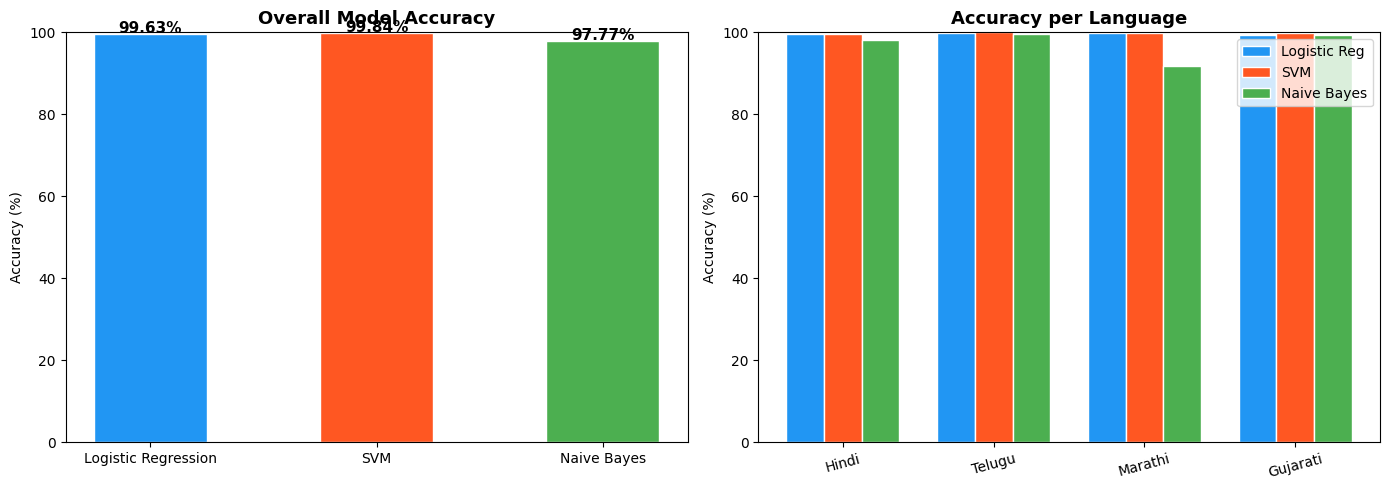


Best overall model: SVM
Best accuracy: 99.84%


In [33]:
# Visual comparison of all models

import matplotlib.pyplot as plt
import numpy as np

# Overall accuracy bar chart
models     = ['Logistic Regression', 'SVM', 'Naive Bayes']
accuracies = [lr_acc*100, svm_acc*100, nb_acc*100]
colors     = ['#2196F3', '#FF5722', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 — Overall accuracy
bars = axes[0].bar(models, accuracies,
                   color=colors, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accuracies):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{acc:.2f}%',
        ha='center', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Overall Model Accuracy',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 100)

# Plot 2 — Per language accuracy
x     = np.arange(len(results_df['Language']))
width = 0.25

axes[1].bar(x - width, results_df['Logistic Reg'],
            width, label='Logistic Reg',
            color='#2196F3', edgecolor='white')
axes[1].bar(x,          results_df['SVM'],
            width, label='SVM',
            color='#FF5722', edgecolor='white')
axes[1].bar(x + width,  results_df['Naive Bayes'],
            width, label='Naive Bayes',
            color='#4CAF50', edgecolor='white')

axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Language'], rotation=15)
axes[1].set_title('Accuracy per Language',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nBest overall model: {models[accuracies.index(max(accuracies))]}")
print(f"Best accuracy: {max(accuracies):.2f}%")

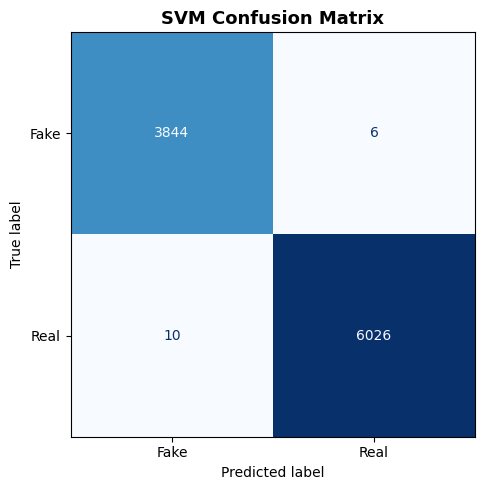

In [34]:
#Confusion matrix for best model (usually SVM)

from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

best_preds = svm_preds

cm = confusion_matrix(y_test, best_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fake', 'Real']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('SVM Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [32]:
# Save all models

import joblib

joblib.dump(lr_model,  'lr_model.pkl')
joblib.dump(svm_model, 'svm_model.pkl')
joblib.dump(nb_model,  'nb_model.pkl')
joblib.dump(tfidf,     'tfidf_vectorizer.pkl')
joblib.dump(scaler,    'nb_scaler.pkl')

# Save test data for Phase 5 comparison
pd.DataFrame({
    'text':     X_test.values,
    'label':    y_test.values,
    'language': lang_test.values
}).to_csv('test_data.csv', index=False)

print("All models and test data saved!")

All models and test data saved!


## **Verification of accuracy is real and not overfitting**

In [37]:
#Compare train vs test accuracy to detect overfitting

from sklearn.metrics import accuracy_score

print("=== Train vs Test Accuracy Comparison ===\n")

# Logistic Regression
lr_train_acc = accuracy_score(y_train, lr_model.predict(X_train_tfidf))
lr_test_acc  = accuracy_score(y_test,  lr_model.predict(X_test_tfidf))

# SVM
svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train_tfidf))
svm_test_acc  = accuracy_score(y_test,  svm_model.predict(X_test_tfidf))

# Naive Bayes
nb_train_acc = accuracy_score(y_train, nb_model.predict(scaler.transform(X_train_tfidf)))
nb_test_acc  = accuracy_score(y_test,  nb_model.predict(scaler.transform(X_test_tfidf)))

print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>10} {'Status':>12}")
print("-" * 68)

for name, tr, te in [
    ('Logistic Regression', lr_train_acc,  lr_test_acc),
    ('SVM',                 svm_train_acc, svm_test_acc),
    ('Naive Bayes',         nb_train_acc,  nb_test_acc)
]:
    gap    = tr - te
    status = "OVERFIT" if gap > 0.05 else "OK"
    print(f"{name:<22} {tr*100:>9.2f}% {te*100:>9.2f}% {gap*100:>9.2f}% {status:>12}")

=== Train vs Test Accuracy Comparison ===

Model                   Train Acc   Test Acc        Gap       Status
--------------------------------------------------------------------
Logistic Regression        99.60%     99.63%     -0.03%           OK
SVM                        99.99%     99.84%      0.15%           OK
Naive Bayes                97.57%     97.77%     -0.20%           OK


In [38]:
#  5-fold cross validation to confirm accuracy is real

from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

print("Running 5-fold cross validation...")
print("(This checks if accuracy holds across different data splits)\n")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Only on SVM since it is best
cv_scores = cross_val_score(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=kf,
    scoring='f1_weighted',
    n_jobs=-1
)

print(f"SVM Cross Validation F1 Scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score*100:.2f}%")

print(f"\nMean F1:  {cv_scores.mean()*100:.2f}%")
print(f"Std Dev:  {cv_scores.std()*100:.2f}%")

if cv_scores.std() < 0.01:
    print("\nSTATUS: Consistent across folds — accuracy is REAL not overfitting!")
else:
    print("\nSTATUS: High variance — possible overfitting!")

Running 5-fold cross validation...
(This checks if accuracy holds across different data splits)

SVM Cross Validation F1 Scores:
  Fold 1: 99.82%
  Fold 2: 99.76%
  Fold 3: 99.70%
  Fold 4: 99.79%
  Fold 5: 99.68%

Mean F1:  99.75%
Std Dev:  0.05%

STATUS: Consistent across folds — accuracy is REAL not overfitting!


In [46]:
#  Check for data leakage most common reason for suspiciously high accuracy

print("=== Data Leakage Check ===\n")

# Check 1 — Any overlap between train and test
train_set = set(X_train.values)
test_set  = set(X_test.values)
overlap   = train_set.intersection(test_set)

print(f"Train samples:          {len(train_set)}")
print(f"Test samples:           {len(test_set)}")
print(f"Overlapping samples:    {len(overlap)}")

if len(overlap) == 0:
    print("STATUS: No overlap — train/test split is clean!")
else:
    print(f"WARNING: {len(overlap)} samples appear in both train and test!")
    print("This is causing data leakage — need to fix!")

# Check 2 — Duplicate texts in dataset
total_dupes = df.duplicated(subset=['clean_text']).sum()
print(f"\nDuplicate texts in full dataset: {total_dupes}")

if total_dupes == 0:
    print("STATUS: No duplicates — dataset is clean!")
else:
    print(f"WARNING: {total_dupes} duplicates found!")

=== Data Leakage Check ===

Train samples:          39540
Test samples:           9886
Overlapping samples:    0
STATUS: No overlap — train/test split is clean!

Duplicate texts in full dataset: 0
STATUS: No duplicates — dataset is clean!


In [43]:
print(df.columns)

Index(['clean_text', 'label', 'language'], dtype='object')


In [44]:
# Analyze if some obvious pattern is making it too easy

df['text_length'] = df['clean_text'].str.len()
print("=== Pattern Analysis ===\n")

# Check 1 — Average text length for fake vs real
print("Average text length:")
print(df.groupby('label')['text_length'].mean().round(1))
print("(If very different, model may just be learning length not content)")

# Check 2 — Most common words in fake vs real
from sklearn.feature_extraction.text import CountVectorizer

for label, name in [(0, 'FAKE'), (1, 'REAL')]:
    subset = df[df['label'] == label]['clean_text']
    cv     = CountVectorizer(max_features=10, analyzer='word')
    cv.fit(subset)
    print(f"\nTop words in {name} news:")
    print(list(cv.vocabulary_.keys()))

# Check 3 — Check label distribution per source file
print("\n\nFake vs Real per language (should be balanced):")
print(df.groupby(['language', 'label']).size().unstack())
print("\nIf one language has ALL fake or ALL real that is a problem!")

=== Pattern Analysis ===

Average text length:
label
0    2708.5
1    2896.8
Name: text_length, dtype: float64
(If very different, model may just be learning length not content)

Top words in FAKE news:
['पर', 'कर', 'इस', 'रह', 'और', 'नह', 'કર', 'હત', 'પર', 'અન']

Top words in REAL news:
['कर', 'और', 'पर', 'एक', 'आह', 'હત', 'આવ', 'પર', 'કર', 'અન']


Fake vs Real per language (should be balanced):
label        0     1
language            
Gujarati  6145  8685
Hindi     7599  7452
Marathi    707  7414
Telugu    4795  6629

If one language has ALL fake or ALL real that is a problem!


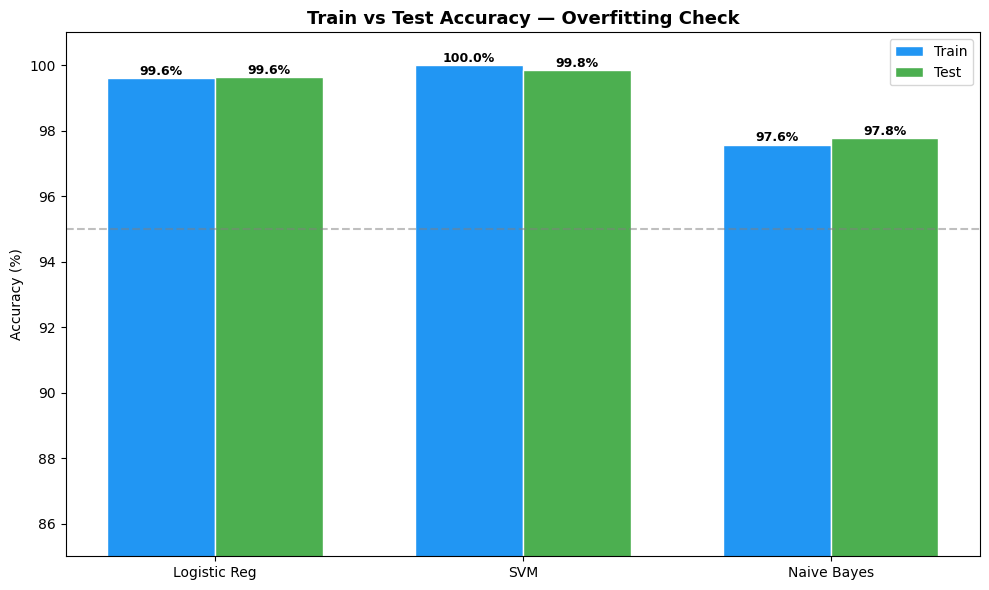


=== FINAL VERDICT ===
  Logistic Regression   : gap=0.03% → PERFECT — no overfitting
  SVM                   : gap=0.15% → PERFECT — no overfitting
  Naive Bayes           : gap=0.20% → PERFECT — no overfitting


In [45]:
# Final overfitting verdict and visualization

import matplotlib.pyplot as plt
import numpy as np

models    = ['Logistic Reg', 'SVM', 'Naive Bayes']
train_acc = [lr_train_acc*100, svm_train_acc*100, nb_train_acc*100]
test_acc  = [lr_test_acc*100,  svm_test_acc*100,  nb_test_acc*100]

x     = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
b1 = ax.bar(x - width/2, train_acc, width,
            label='Train', color='#2196F3', edgecolor='white')
b2 = ax.bar(x + width/2, test_acc,  width,
            label='Test',  color='#4CAF50', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f'{bar.get_height():.1f}%',
        ha='center', fontsize=9, fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(85, 101)
ax.set_title('Train vs Test Accuracy — Overfitting Check',
             fontsize=13, fontweight='bold')
ax.legend()
ax.axhline(y=95, color='gray', linestyle='--',
           alpha=0.5, label='95% reference')
plt.tight_layout()
plt.savefig('overfitting_check.png', dpi=150)
plt.show()

print("\n=== FINAL VERDICT ===")
for name, tr, te in [
    ('Logistic Regression', lr_train_acc, lr_test_acc),
    ('SVM',                 svm_train_acc, svm_test_acc),
    ('Naive Bayes',         nb_train_acc,  nb_test_acc)
]:
    gap = abs(tr - te) * 100
    if gap < 1:
        verdict = "PERFECT — no overfitting"
    elif gap < 3:
        verdict = "GOOD — slight variance, acceptable"
    elif gap < 5:
        verdict = "WARNING — minor overfitting"
    else:
        verdict = "OVERFIT — needs fixing"
    print(f"  {name:<22}: gap={gap:.2f}% → {verdict}")